<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/DifferentNormalizationMethods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


#Expeiment Configuration


In [2]:
SEED = 42
EPOCHS = 15
BATCH_SIZE = 128
LEARNING_RATE = 0.05
TARGET_VALIDATION_ACCURACY = 0.95
INITIALIZATION_METHODS = [
    "Random",
    "Xavier",
    "He",
    "Zero"
]


# Reduce unnecessary TensorFlow messages

In [4]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

#Set random seeds

In [6]:
import random

def set_seed(seed: int) -> None:
    """
    Set random seeds for reproducibility.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


set_seed(SEED)

# 3. Load and preprocess the MNIST dataset

In [7]:
print("\nLoading MNIST dataset...")

(x_train_full, y_train_full), (x_test, y_test) = (
keras.datasets.mnist.load_data()
)

# Convert pixel values from [0, 255] to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Use 5,000 samples for validation
x_train = x_train_full[:-5000]
y_train = y_train_full[:-5000]

x_validation = x_train_full[-5000:]
y_validation = y_train_full[-5000:]

print("Training samples  :", x_train.shape[0])
print("Validation samples:", x_validation.shape[0])
print("Testing samples   :", x_test.shape[0])



Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples  : 55000
Validation samples: 5000
Testing samples   : 10000


#Create initializer

In [13]:
def get_initializer(method: str, seed: int):
    """
    Return the required kernel initializer.

    Parameters
    ----------
method : str
        Random, Xavier, He, or Zero.
seed : int
        Seed used for reproducibility.

    Returns
    -------
keras.initializers.Initializer
        Selected initializer object.
    """

    if method == "Random":
        return keras.initializers.RandomNormal(
            mean=0.0,
            stddev=0.05,
            seed=seed
        )

    if method == "Xavier":
        return keras.initializers.GlorotUniform(
            seed=seed
        )

    if method == "He":
        return keras.initializers.HeNormal(
            seed=seed
        )

    if method == "Zero":
        return keras.initializers.Zeros()

    raise ValueError(
        f"Unknown initialization method: {method}"
    )


# ---------------------------------------------------------
# 5. Build the neural-network model
# ---------------------------------------------------------

def build_model(initialization_method: str) -> keras.Model:
    """
    Build the same neural-network architecture using the
    specified initialization method.

    Architecture:
    Input 28 x 28
        ↓
    Flatten
        ↓
    Dense 256, ReLU
        ↓
    Dense 128, ReLU
        ↓
    Dense 10, Softmax
    """

    model = keras.Sequential(
        [
            keras.Input(shape=(28, 28)),

            layers.Flatten(name="flatten"),

            layers.Dense(
                units=256,
                activation="relu",
                kernel_initializer=get_initializer(
                    initialization_method,
                    SEED + 1
                ),
                bias_initializer="zeros",
                name="hidden_layer_1"
            ),

            layers.Dense(
                units=128,
                activation="relu",
                kernel_initializer=get_initializer(
                    initialization_method,
                    SEED + 2
                ),
                bias_initializer="zeros",
                name="hidden_layer_2"
            ),

            layers.Dense(
                units=10,
                activation="softmax",
                kernel_initializer=get_initializer(
                    initialization_method,
                    SEED + 3
                ),
                bias_initializer="zeros",
                name="output_layer"
            )
        ],
        name=f"{initialization_method.lower()}_initialization_model"
    )

    # SGD is used because initialization effects are usually
    # easier to observe than when using a highly adaptive optimizer.
    optimizer = keras.optimizers.SGD(
        learning_rate=LEARNING_RATE,
        momentum=0.9
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#Find convergence epoch

In [9]:
def find_convergence_epoch(
validation_accuracies,
target_accuracy=0.95
):
    """
    Return the first epoch at which validation accuracy
    reaches the specified target.

    If the target is not reached, return None.
    """

    for epoch_number, accuracy in enumerate(
validation_accuracies,
        start=1
    ):
        if accuracy >= target_accuracy:
            return epoch_number

    return None


#Train models using different initialization methods

In [14]:
import gc
import time

histories = {}
results = []

for method_number, method in enumerate(
    INITIALIZATION_METHODS,
    start=1
):
    print("\n" + "=" * 70)
    print(
        f"Experiment {method_number}/{len(INITIALIZATION_METHODS)}"
    )
    print(f"Initialization method: {method}")
    print("=" * 70)

    # Remove the previous model from memory
    keras.backend.clear_session()
    gc.collect()

    # Reset seeds so all models receive the same data order
    set_seed(SEED)

    model = build_model(method)

    if method_number == 1:
        print("\nModel architecture:")
        model.summary()

    start_time = time.perf_counter()

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_validation, y_validation),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=2
    )

    training_time = time.perf_counter() - start_time

    # Evaluate on unseen test data
    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    # Store training history
    histories[method] = history.history

    convergence_epoch = find_convergence_epoch(
        history.history["val_accuracy"],
        TARGET_VALIDATION_ACCURACY
    )

    result = {
        "Initialization": method,
        "Initial Training Loss": history.history["loss"][0],
        "Final Training Loss": history.history["loss"][-1],
        "Final Validation Loss": history.history["val_loss"][-1],
        "Final Training Accuracy": history.history["accuracy"][-1],
        "Final Validation Accuracy": history.history[
            "val_accuracy"
        ][-1],
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy,
        "Epoch Reaching 95% Validation Accuracy":
            convergence_epoch
            if convergence_epoch is not None
            else "Not reached",
        "Training Time in Seconds": training_time
    }

    results.append(result)

    print(f"\nResults for {method} initialization")
    print(f"Test loss     : {test_loss:.4f}")
    print(f"Test accuracy : {test_accuracy:.4f}")
    print(f"Training time : {training_time:.2f} seconds")

    if convergence_epoch is not None:
        print(
            f"Reached {TARGET_VALIDATION_ACCURACY:.0%} "
            f"validation accuracy at epoch "
            f"{convergence_epoch}"
        )
    else:
        print(
            f"Did not reach "
            f"{TARGET_VALIDATION_ACCURACY:.0%} "
            f"validation accuracy"
        )



Experiment 1/4
Initialization method: Random

Model architecture:


Model: "random_initialization_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
430/430 - 5s - 11ms/step - accuracy: 0.8893 - loss: 0.3632 - val_accuracy: 0.9626 - val_loss: 0.1417
Epoch 2/15
430/430 - 3s - 6ms/step - accuracy: 0.9650 - loss: 0.1154 - val_accuracy: 0.9762 - val_loss: 0.0895
Epoch 3/15
430/430 - 3s - 6ms/step - accuracy: 0.9764 - loss: 0.0770 - val_accuracy: 0.9780 - val_loss: 0.0779
Epoch 4/15
430/430 - 3s - 6ms/step - accuracy: 0.9834 - loss: 0.0543 - val_accuracy: 0.9780 - val_loss: 0.0740
Epoch 5/15
430/430 - 5s - 12ms/step - accuracy: 0.9881 - loss: 0.0394 - val_accuracy: 0.9796 - val_loss: 0.0788
Epoch 6/15
430/430 - 3s - 6ms/step - accuracy: 0.9915 - loss: 0.0287 - val_accuracy: 0.9794 - val_loss: 0.0751
Epoch 7/15
430/430 - 3s - 6ms/step - accuracy: 0.9934 - loss: 0.0220 - val_accuracy: 0.9790 - val_loss: 0.0837
Epoch 8/15
430/430 - 4s - 8ms/step - accuracy: 0.9955 - loss: 0.0165 - val_accuracy: 0.9770 - val_loss: 0.0997
Epoch 9/15
430/430 - 3s - 7ms/step - accuracy: 0.9961 - loss: 0.0136 - val_accuracy: 0.9736 - val_loss: 0.1186

#Create comparison table

In [15]:
results_dataframe = pd.DataFrame(results)

# Sort according to test accuracy
results_dataframe = results_dataframe.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 4)

print("\n" + "=" * 100)
print("FINAL COMPARISON OF INITIALIZATION METHODS")
print("=" * 100)

print(
results_dataframe[
        [
            "Initialization",
            "Final Training Loss",
            "Final Validation Loss",
            "Final Training Accuracy",
            "Final Validation Accuracy",
            "Test Accuracy",
            "Epoch Reaching 95% Validation Accuracy",
            "Training Time in Seconds"
        ]
    ].to_string(index=False)
)



FINAL COMPARISON OF INITIALIZATION METHODS
Initialization  Final Training Loss  Final Validation Loss  Final Training Accuracy  Final Validation Accuracy  Test Accuracy Epoch Reaching 95% Validation Accuracy  Training Time in Seconds
            He               0.0014                 0.0802                   0.9999                     0.9848         0.9824                                      1                   52.0572
        Random               0.0021                 0.0825                   0.9996                     0.9830         0.9817                                      1                   49.8368
        Xavier               0.0028                 0.0908                   0.9995                     0.9818         0.9785                                      1                   53.0749
          Zero               2.3022                 2.3026                   0.1105                     0.1060         0.1135                            Not reached                   52.4752


#Save numerical results

In [16]:
results_dataframe.to_csv(
    "initialization_comparison_results.csv",
    index=False
)

print(
    "\nResults saved as: "
    "initialization_comparison_results.csv"
)



Results saved as: initialization_comparison_results.csv


#Plot loss and accuracy curves

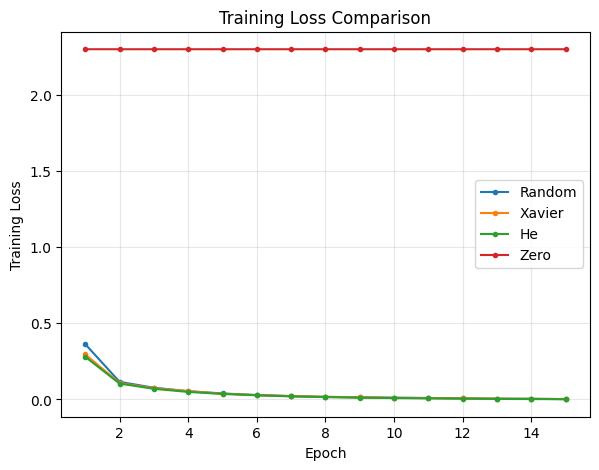

In [18]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(15, 11))

# Training loss
plt.subplot(2, 2, 1)

for method in INITIALIZATION_METHODS:
    plt.plot(
        epochs_range,
        histories[method]["loss"],
        marker="o",
        markersize=3,
        label=method
    )

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True, alpha=0.3)
plt.legend()


#Validation loss

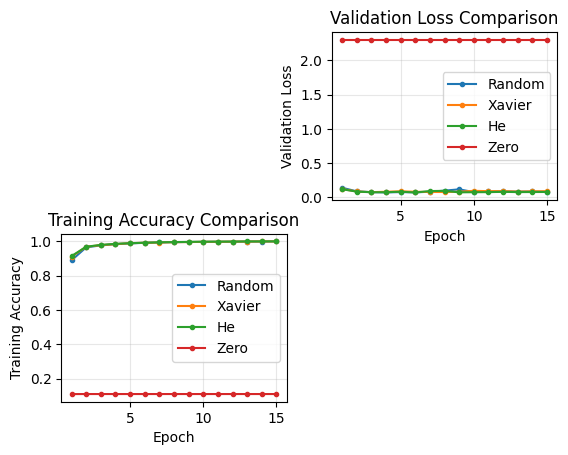

In [20]:

plt.subplot(2, 2, 2)

for method in INITIALIZATION_METHODS:
    plt.plot(
        epochs_range,
        histories[method]["val_loss"],
        marker="o",
        markersize=3,
        label=method
    )

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()


# Training accuracy
plt.subplot(2, 2, 3)

for method in INITIALIZATION_METHODS:
    plt.plot(
        epochs_range,
        histories[method]["accuracy"],
        marker="o",
        markersize=3,
        label=method
    )

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()


#Validation accuracy

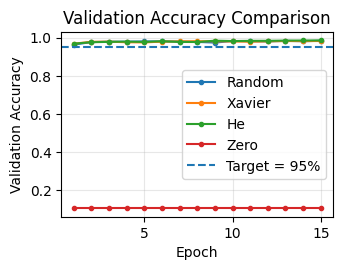

Convergence graph saved as: initialization_convergence_curves.png


In [22]:
plt.subplot(2, 2, 4)

for method in INITIALIZATION_METHODS:
    plt.plot(
        epochs_range,
        histories[method]["val_accuracy"],
        marker="o",
        markersize=3,
        label=method
    )

plt.axhline(
    y=TARGET_VALIDATION_ACCURACY,
    linestyle="--",
    label=f"Target = {TARGET_VALIDATION_ACCURACY:.0%}"
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "initialization_convergence_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Convergence graph saved as: "
    "initialization_convergence_curves.png"
)


#Plot final test accuracy

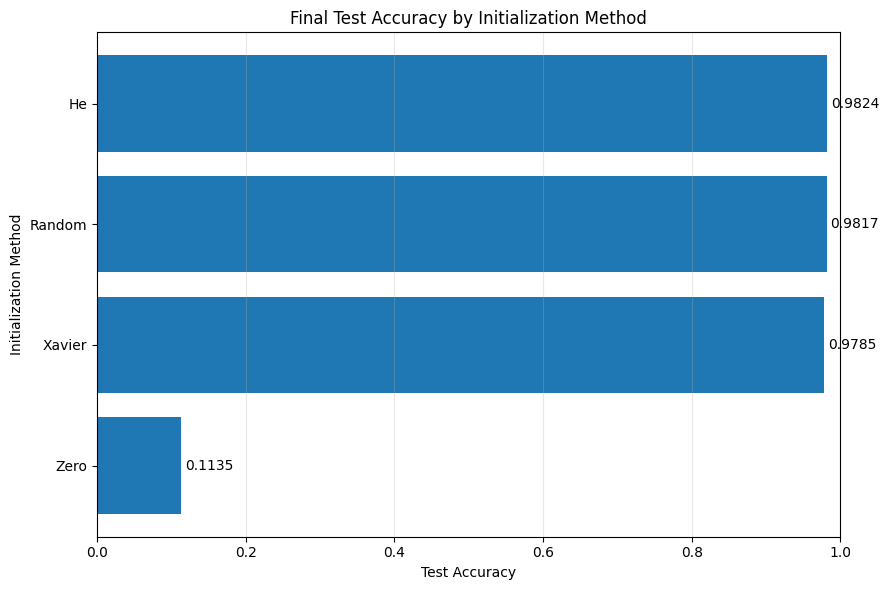

Test-accuracy graph saved as: initialization_test_accuracy.png


In [24]:
plot_dataframe = results_dataframe.sort_values(
    by="Test Accuracy",
    ascending=True
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    plot_dataframe["Initialization"],
    plot_dataframe["Test Accuracy"]
)

plt.title("Final Test Accuracy by Initialization Method")
plt.xlabel("Test Accuracy")
plt.ylabel("Initialization Method")
plt.xlim(0, 1.0)
plt.grid(axis="x", alpha=0.3)

for bar, accuracy in zip(
    bars,
    plot_dataframe["Test Accuracy"]
):
    plt.text(
        accuracy + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{accuracy:.4f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "initialization_test_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Test-accuracy graph saved as: "
    "initialization_test_accuracy.png"
)


#Print interpretation

In [25]:
print("\n" + "=" * 100)
print("INTERPRETATION")
print("=" * 100)



INTERPRETATION
